<a href="https://colab.research.google.com/github/Isaq0711/processamento-sinais-I/blob/main/aula-03/codigo/aula_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP3 — Transformada z
**Processamento de Sinais I — Prof. Rafael S. Chaves**  
Autores: Isaque Soares, Guilherme Archanjo e Marcelo Auday  

Resolução prática e computacional da AP3: análise de polos e zeros, resposta em frequência, filtragem inversa e aproximações FIR.

In [13]:
# Setup e importações
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import freqz, lfilter, fftconvolve
from IPython.display import Audio, display

PASTA_DADOS = "dados"

In [14]:
# Funções utilitárias
def ler_wav(nome_arquivo):
    """Lê um arquivo WAV, converte para mono e normaliza para [-1, 1]."""
    caminho = os.path.join(PASTA_DADOS, nome_arquivo)
    if not os.path.exists(caminho):
        caminho = nome_arquivo
    fs, x = wavfile.read(caminho)
    if x.ndim > 1:
        x = x[:, 0]
    if np.issubdtype(x.dtype, np.integer):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)
    return fs, x

def tocar(x, fs):
    """Reproduz sinal de áudio inline no notebook."""
    display(Audio(x, rate=fs))

def calculate_spectrum(x, fs, titulo="Espectro", xlim=None, escala_db=True):
    """Calcula e exibe o espectro de magnitude via FFT."""
    n = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(X) / n

    plt.figure(figsize=(7, 3.2))
    if escala_db:
        plt.plot(freqs, 20 * np.log10(mag + 1e-12), linewidth=0.8)
        plt.ylabel("Magnitude (dB)")
    else:
        plt.plot(freqs, mag, linewidth=0.8)
        plt.ylabel("Magnitude")
    plt.xlabel("Frequência (Hz)")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()
    return freqs, mag

def plot_zplane(b, a, titulo="Diagrama de Polos e Zeros"):
    """Plota zeros e polos no plano complexo com o círculo unitário."""
    zeros = np.roots(b)
    polos = np.roots(a)

    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(np.cos(theta), np.sin(theta), '--', color='gray', label='Círculo Unitário')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.6, alpha=0.4)

    if len(zeros) > 0:
        ax.scatter(np.real(zeros), np.imag(zeros), s=55, facecolors='none', edgecolors='#1f77b4', linewidths=1.5, label=f'Zeros ({len(zeros)})', zorder=3)
    if len(polos) > 0:
        ax.scatter(np.real(polos), np.imag(polos), s=55, marker='x', color='#d62728', linewidths=1.5, label=f'Polos ({len(polos)})', zorder=3)

    ax.set_xlabel("Parte Real")
    ax.set_ylabel("Parte Imaginária")
    ax.set_title(titulo)
    ax.set_aspect('equal', 'box')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    return zeros, polos

def plot_freq_response(b, a, fs=None, titulo="Resposta em Frequência"):
    """Plota a resposta em magnitude (dB) e fase (rad)."""
    w, h = freqz(b, a, worN=2048)
    eixo_x = (w * fs / (2 * np.pi)) if fs is not None else w
    label_x = "Frequência (Hz)" if fs is not None else "Frequência Normalizada (rad/amostra)"

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True)
    ax1.plot(eixo_x, 20 * np.log10(np.abs(h) + 1e-12), linewidth=0.9)
    ax1.set_ylabel("Magnitude (dB)")
    ax1.set_title(titulo)
    ax1.grid(True, alpha=0.3)

    ax2.plot(eixo_x, np.unwrap(np.angle(h)), color='C1', linewidth=0.9)
    ax2.set_xlabel(label_x)
    ax2.set_ylabel("Fase (rad)")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def calcular_metricas(x_orig, x_rec):
    """Calcula erro quadrático médio (MSE) e relação sinal-ruído (SNR)."""
    n = min(len(x_orig), len(x_rec))
    e = x_orig[:n] - x_rec[:n]
    mse = np.mean(e**2)
    snr = 10 * np.log10(np.mean(x_orig[:n]**2) / (mse + 1e-30))
    return snr, mse

## Questão 1 — Resposta em frequência e polos e zeros de H(z)
$$H(z) = 1 + 0.49z^{-2} + 0.2401z^{-6} - 0.0576z^{-8} - 0.0282z^{-10} - 0.0138z^{-12}$$

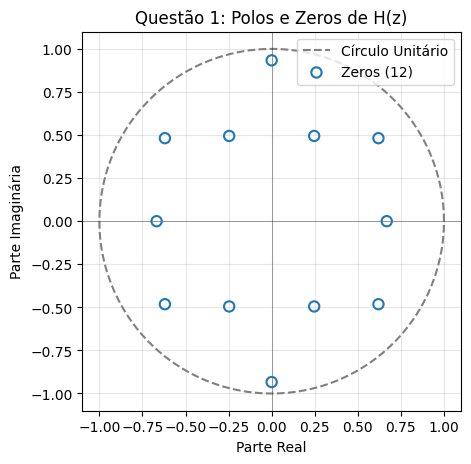

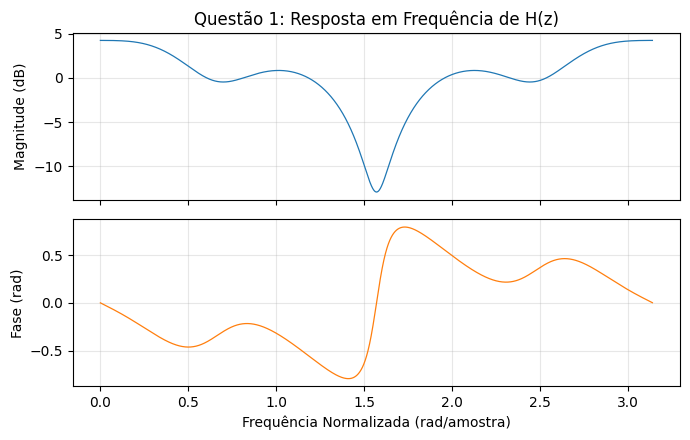

Raio máximo dos zeros: 0.9336
Classificação: Sistema de FASE MÍNIMA (todos os zeros estritamente dentro do círculo unitário).


In [15]:
b_q1 = np.zeros(13)
b_q1[0] = 1.0
b_q1[2] = 0.49
b_q1[6] = 0.2401
b_q1[8] = -0.0576
b_q1[10] = -0.0282
b_q1[12] = -0.0138
a_q1 = np.array([1.0])

zeros_q1, polos_q1 = plot_zplane(b_q1, a_q1, titulo="Questão 1: Polos e Zeros de H(z)")
plot_freq_response(b_q1, a_q1, titulo="Questão 1: Resposta em Frequência de H(z)")

r_max = np.max(np.abs(zeros_q1))
print(f"Raio máximo dos zeros: {r_max:.4f}")
if r_max < 1.0:
    print("Classificação: Sistema de FASE MÍNIMA (todos os zeros estritamente dentro do círculo unitário).")
else:
    print("Classificação: Sistema NÃO é de fase mínima.")

## Questão 2 — Filtragem de handel.wav com H(z)

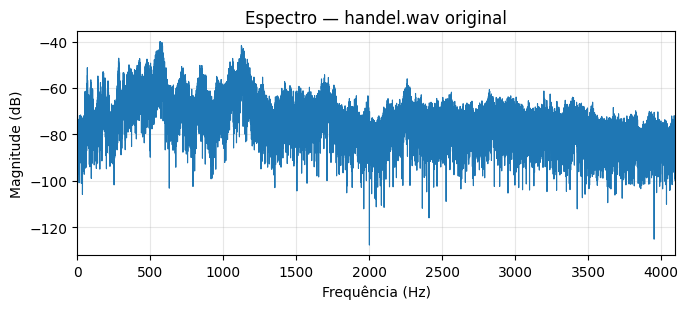

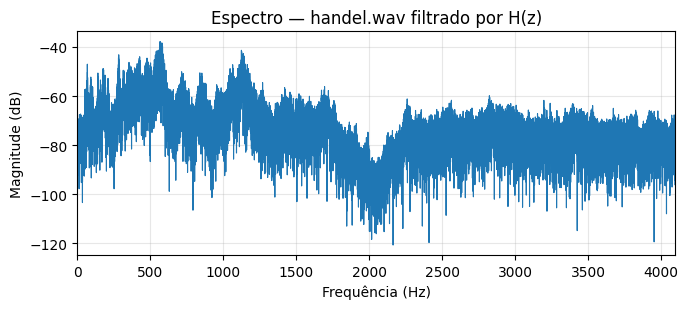

Áudio Original:


Áudio Filtrado:


In [16]:
fs_h, x_h = ler_wav("handel.wav")
y_q2 = lfilter(b_q1, a_q1, x_h)

calculate_spectrum(x_h, fs_h, titulo="Espectro — handel.wav original", xlim=(0, fs_h/2))
calculate_spectrum(y_q2, fs_h, titulo="Espectro — handel.wav filtrado por H(z)", xlim=(0, fs_h/2))

print("Áudio Original:")
tocar(x_h, fs_h)
print("Áudio Filtrado:")
tocar(y_q2, fs_h)

## Questão 3 — Filtro Inverso e Recuperação do Áudio Original

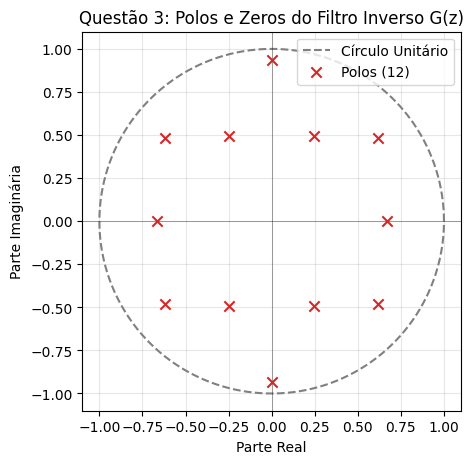

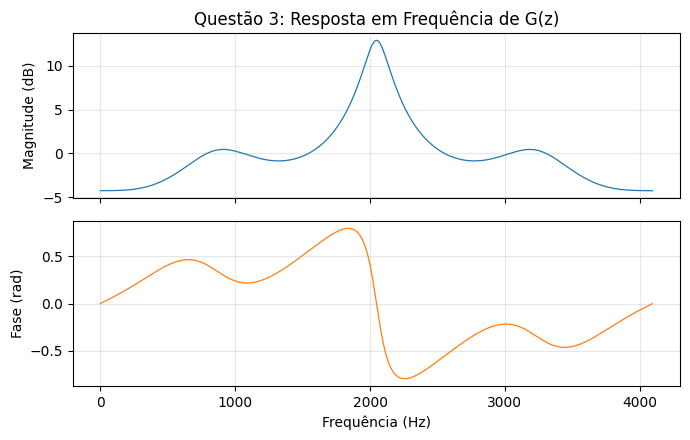

MSE: 4.8438e-34
SNR: 285.85 dB


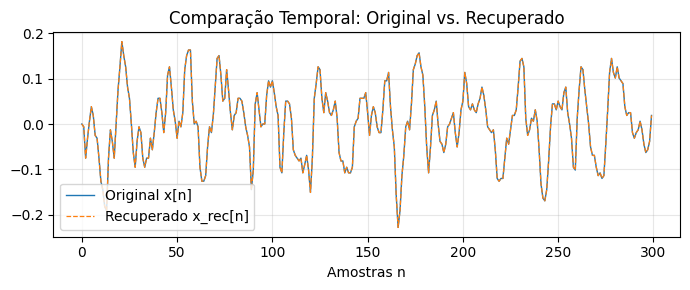

Áudio Recuperado:


In [17]:
# G(z) = 1 / H(z)
b_inv = np.array([1.0])
a_inv = b_q1.copy()

plot_zplane(b_inv, a_inv, titulo="Questão 3: Polos e Zeros do Filtro Inverso G(z)")
plot_freq_response(b_inv, a_inv, fs=fs_h, titulo="Questão 3: Resposta em Frequência de G(z)")

x_rec_q3 = lfilter(b_inv, a_inv, y_q2)
snr_q3, mse_q3 = calcular_metricas(x_h, x_rec_q3)
print(f"MSE: {mse_q3:.4e}")
print(f"SNR: {snr_q3:.2f} dB")

plt.figure(figsize=(7, 3))
plt.plot(x_h[:300], label="Original x[n]", linewidth=1.0)
plt.plot(x_rec_q3[:300], '--', label="Recuperado x_rec[n]", linewidth=0.9)
plt.title("Comparação Temporal: Original vs. Recuperado")
plt.xlabel("Amostras n")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Áudio Recuperado:")
tocar(x_rec_q3, fs_h)

## Questões 4 e 5 — Filtros Pente IIR e Filtragem de handel.wav
$$H(z) = \frac{1 - z^{-L}}{1 - a z^{-L}}$$

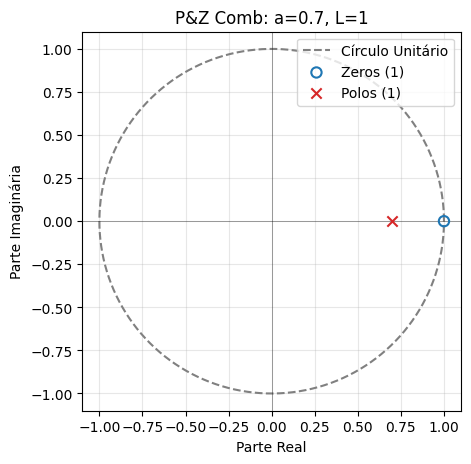

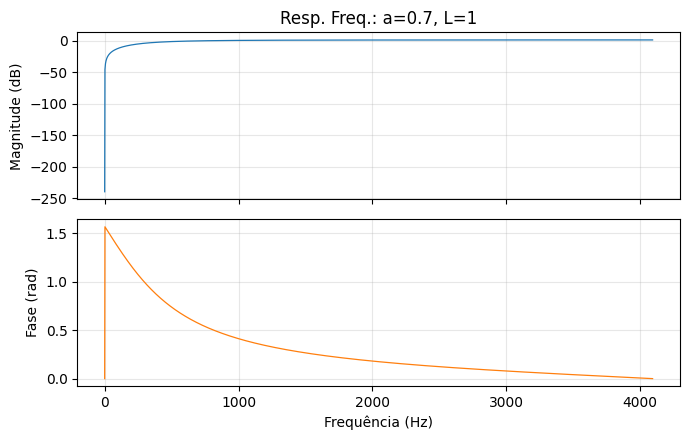

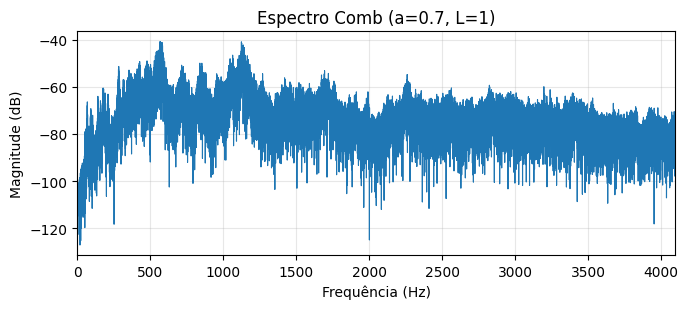

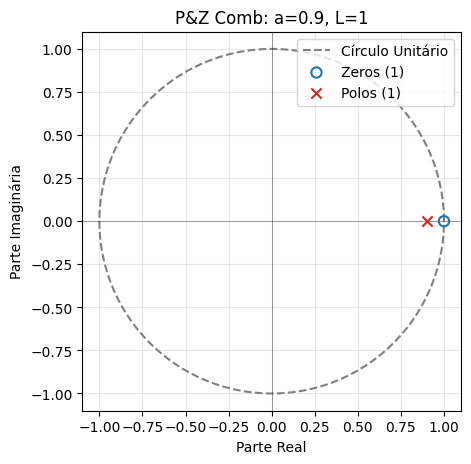

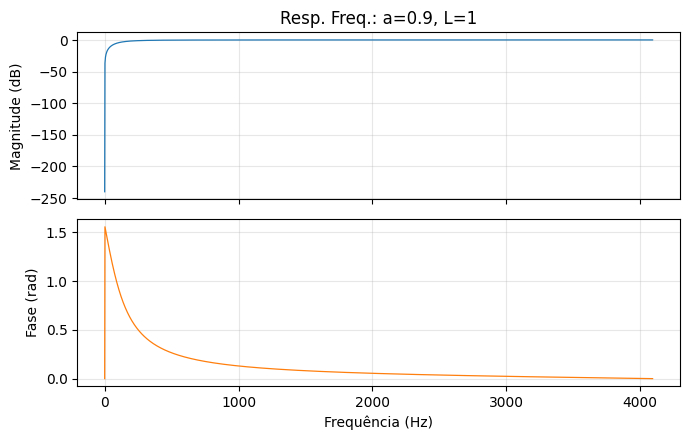

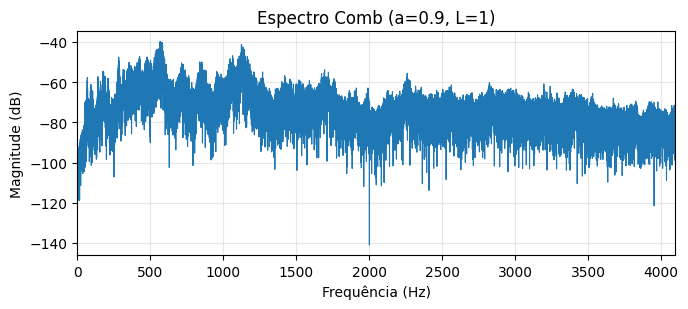

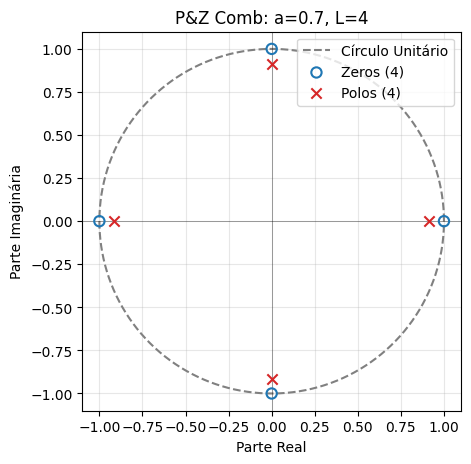

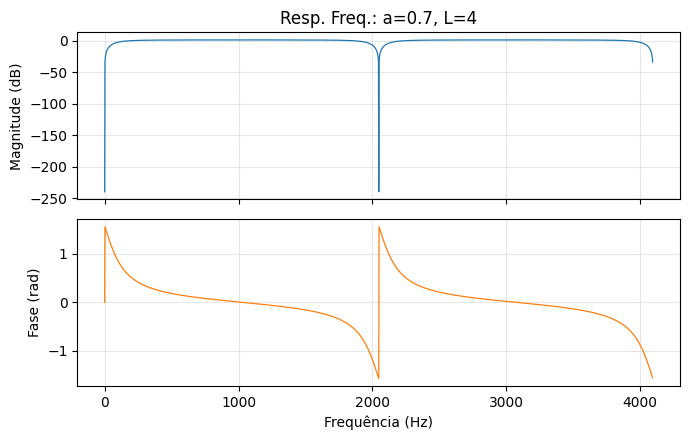

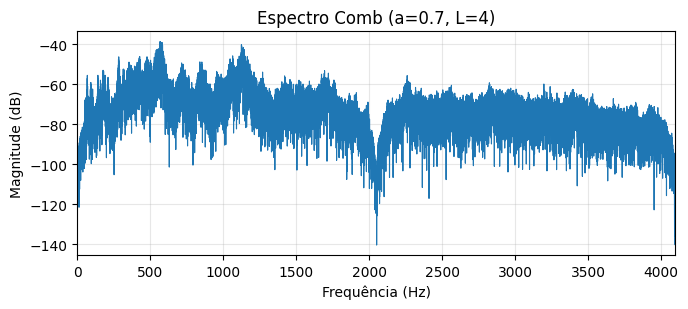

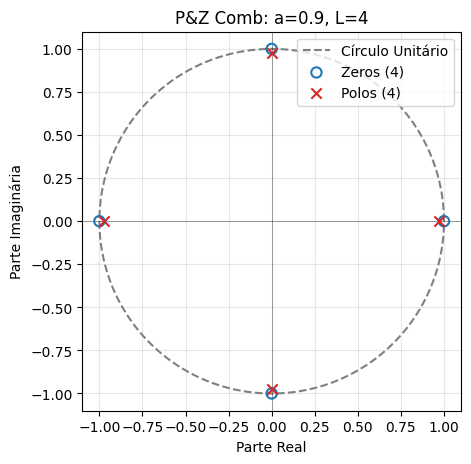

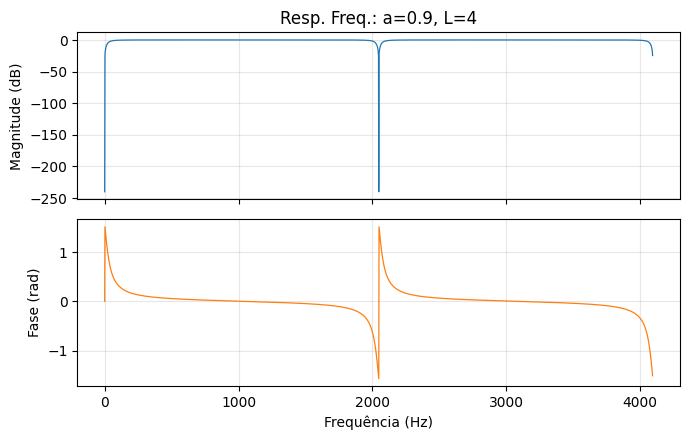

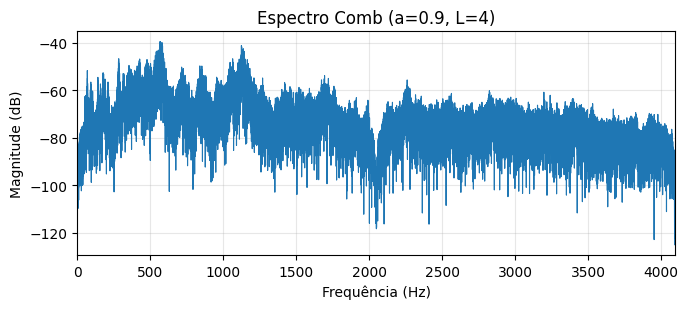

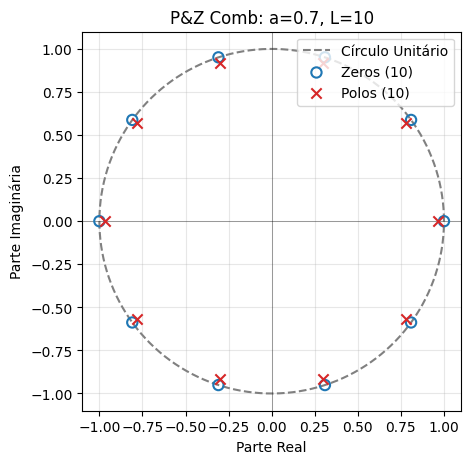

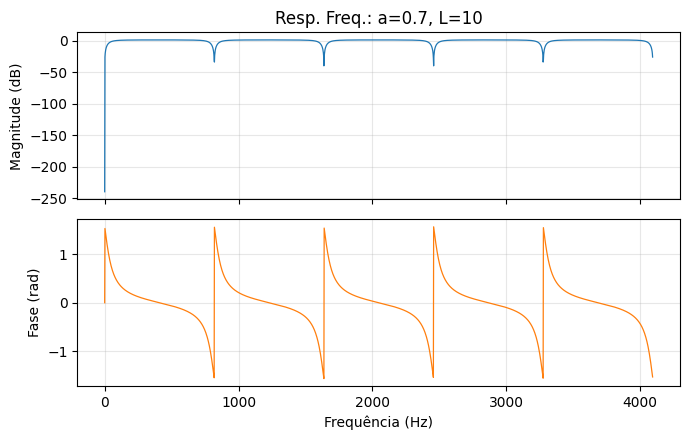

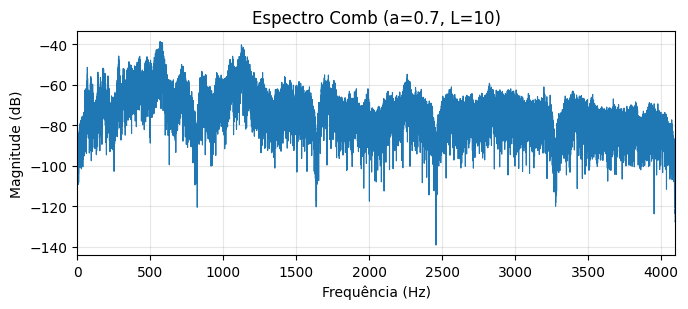

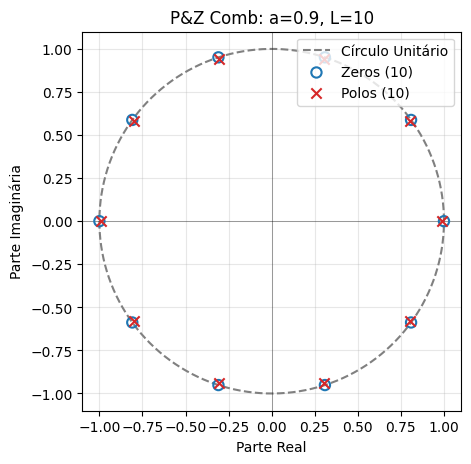

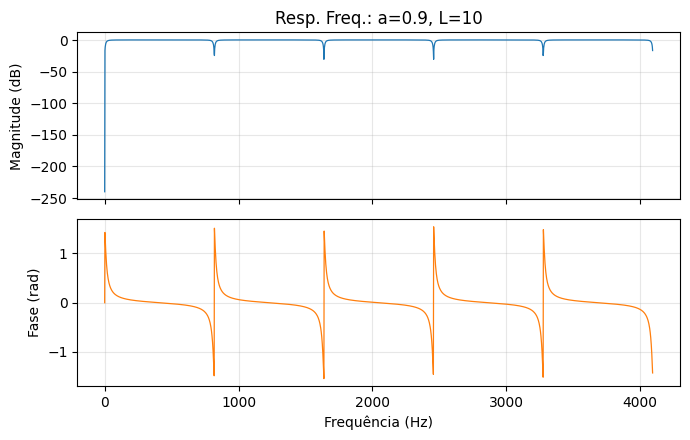

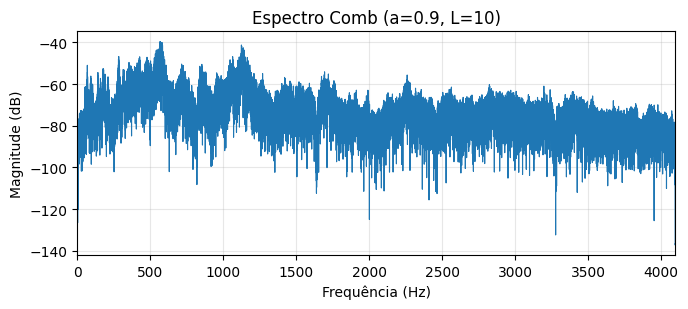

In [18]:
valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]
sistemas_comb = {}
sinais_comb = {}

for L in valores_L:
    for a in valores_a:
        b_c = np.zeros(L + 1)
        b_c[0], b_c[-1] = 1.0, -1.0
        a_c = np.zeros(L + 1)
        a_c[0], a_c[-1] = 1.0, -a
        sistemas_comb[(a, L)] = (b_c, a_c)

        plot_zplane(b_c, a_c, titulo=f"P&Z Comb: a={a}, L={L}")
        plot_freq_response(b_c, a_c, fs=fs_h, titulo=f"Resp. Freq.: a={a}, L={L}")

        # Questão 5
        y_c = lfilter(b_c, a_c, x_h)
        sinais_comb[(a, L)] = y_c
        calculate_spectrum(y_c, fs_h, titulo=f"Espectro Comb (a={a}, L={L})", xlim=(0, fs_h/2))

## Questão 6 — Filtros Inversos dos Sistemas Pente

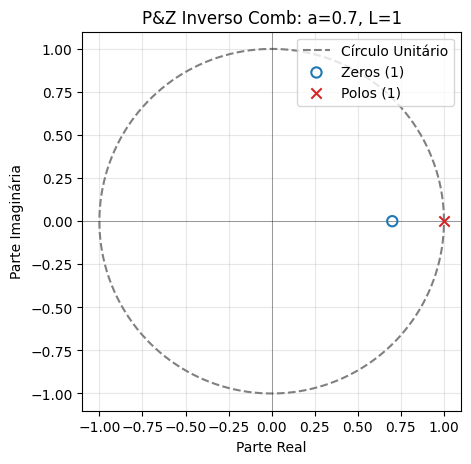

Comb a=0.7, L=1 -> SNR (sem ruído): 277.45 dB (Polos em |z|=1: Marginalmente Estável)


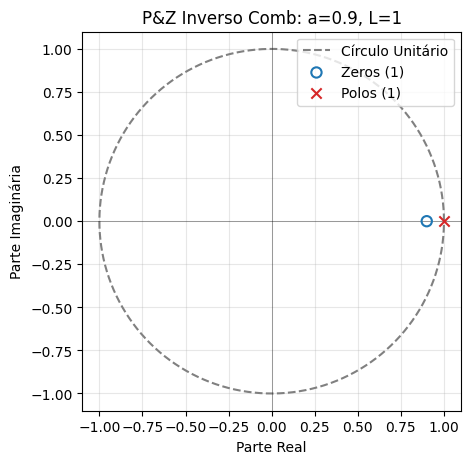

Comb a=0.9, L=1 -> SNR (sem ruído): 274.48 dB (Polos em |z|=1: Marginalmente Estável)


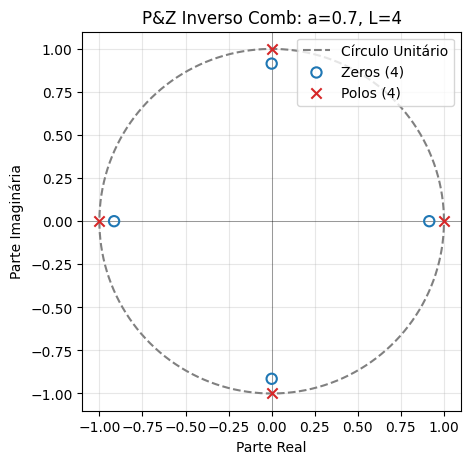

Comb a=0.7, L=4 -> SNR (sem ruído): 282.14 dB (Polos em |z|=1: Marginalmente Estável)


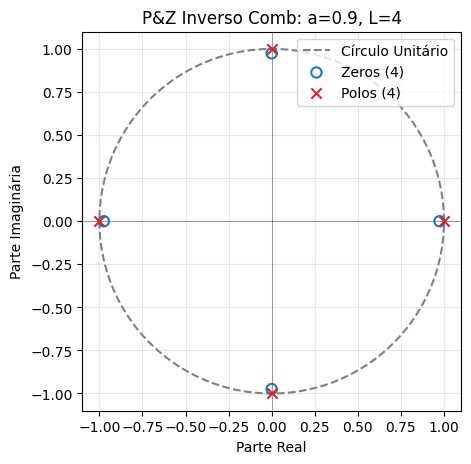

Comb a=0.9, L=4 -> SNR (sem ruído): 284.09 dB (Polos em |z|=1: Marginalmente Estável)


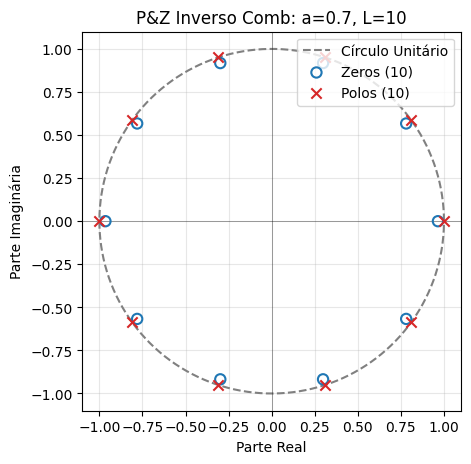

Comb a=0.7, L=10 -> SNR (sem ruído): 283.32 dB (Polos em |z|=1: Marginalmente Estável)


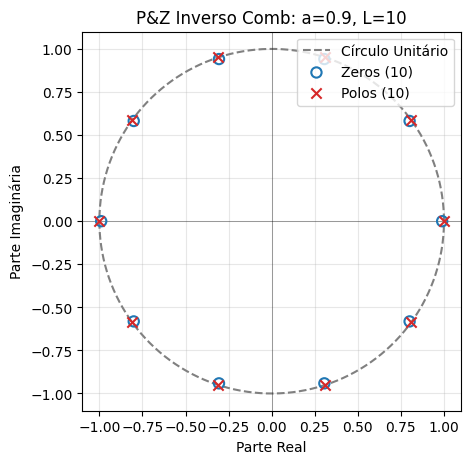

Comb a=0.9, L=10 -> SNR (sem ruído): 283.91 dB (Polos em |z|=1: Marginalmente Estável)


In [19]:
for (a, L), (b_c, a_c) in sistemas_comb.items():
    b_inv_c, a_inv_c = a_c.copy(), b_c.copy()
    plot_zplane(b_inv_c, a_inv_c, titulo=f"P&Z Inverso Comb: a={a}, L={L}")
    y_c = sinais_comb[(a, L)]
    x_rec_c = lfilter(b_inv_c, a_inv_c, y_c)
    snr_c, mse_c = calcular_metricas(x_h, x_rec_c)
    print(f"Comb a={a}, L={L} -> SNR (sem ruído): {snr_c:.2f} dB (Polos em |z|=1: Marginalmente Estável)")

## Questão 7 — Aproximações FIR dos Filtros Inversos

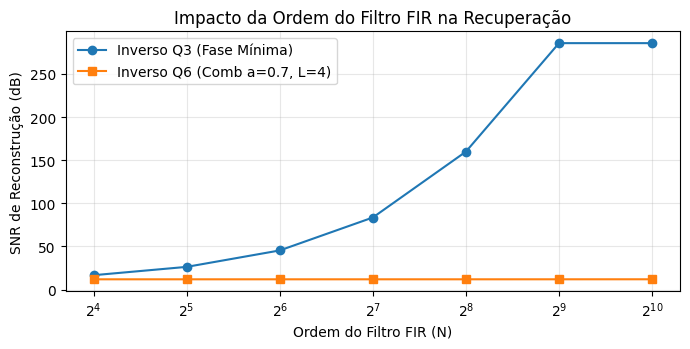

In [20]:
ordens_fir = [16, 32, 64, 128, 256, 512, 1024]

def fir_inverso(b_i, a_i, N):
    impulse = np.zeros(N)
    impulse[0] = 1.0
    return lfilter(b_i, a_i, impulse)

# FIR para Q3 (Fase Mínima)
snrs_fir_q3 = []
for N in ordens_fir:
    h_fir = fir_inverso(b_inv, a_inv, N)
    x_fir = fftconvolve(y_q2, h_fir, mode='full')[:len(x_h)]
    snr_val, _ = calcular_metricas(x_h, x_fir)
    snrs_fir_q3.append(snr_val)

# FIR para Q6 (Comb a=0.7, L=4)
b_c_ex, a_c_ex = sistemas_comb[(0.7, 4)]
snrs_fir_q6 = []
for N in ordens_fir:
    h_fir_c = fir_inverso(a_c_ex, b_c_ex, N)
    x_fir_c = fftconvolve(sinais_comb[(0.7, 4)], h_fir_c, mode='full')[:len(x_h)]
    snr_val, _ = calcular_metricas(x_h, x_fir_c)
    snrs_fir_q6.append(snr_val)

plt.figure(figsize=(7, 3.6))
plt.plot(ordens_fir, snrs_fir_q3, 'o-', label="Inverso Q3 (Fase Mínima)")
plt.plot(ordens_fir, snrs_fir_q6, 's-', label="Inverso Q6 (Comb a=0.7, L=4)")
plt.xscale('log', base=2)
plt.xlabel("Ordem do Filtro FIR (N)")
plt.ylabel("SNR de Reconstrução (dB)")
plt.title("Impacto da Ordem do Filtro FIR na Recuperação")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()